In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

os.chdir('/Users/fogellmcmuffin/Documents/thesis/_replication/')    # Working dir

parameters = pd.read_csv('output/parameters.csv')
mean_spf_trim = pd.read_csv('cleaned_data/mean_spf_trim.csv')
ind_spf_trim = pd.read_csv('cleaned_data/ind_spf_trim.csv')
vintage_trim = pd.read_csv('cleaned_data/vintage_trim.csv')
mean_estimations = pd.read_csv('output/mean_estimations.csv')
ind_est_pld = pd.read_csv('output/ind_est_pld.csv')
ind_est_fe = pd.read_csv('output/ind_est_fe.csv')
ind_est_fe2 = pd.read_csv('output/ind_est_fe2.csv')
ar_table = pd.read_csv('output/ar_estimations.csv')

mean_spf_trim['DATE'] = pd.to_datetime(mean_spf_trim['DATE'])
ind_spf_trim['DATE'] = pd.to_datetime(ind_spf_trim['DATE'])
mean_spf_trim = mean_spf_trim.set_index('DATE')
ind_spf_trim = ind_spf_trim.set_index('DATE')
vintage_trim = vintage_trim.set_index(pd.to_datetime(vintage_trim['DATE']))

# __I. Scatter Plots__

## A. Revisions & Errors

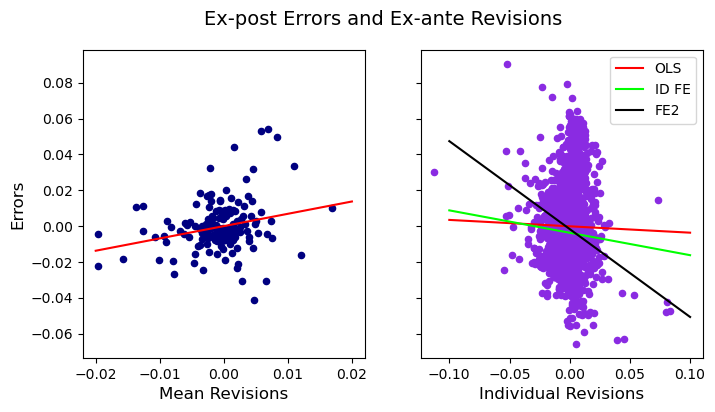

In [2]:
fig, (axm, axi) = plt.subplots(nrows=1, sharey=True, ncols=2, figsize=(8, 4))
fig.suptitle('Ex-post Errors and Ex-ante Revisions', fontsize=14)

### Mean ###
xm = mean_spf_trim['r_t3'][1:]
ym = mean_spf_trim['e_t3'][1:]

axm.scatter(xm, ym, c='navy', alpha=1, s=20)
model_m = mean_estimations.loc[0, 'coef_t3'] + mean_estimations.loc[1, 'coef_t3'] * np.linspace(-0.02, 0.02)
axm.plot(np.linspace(-0.02, 0.02),  model_m, color='red', lw=1.5)

axm.set_xlabel('Mean Revisions', fontsize=12)
axm.set_ylabel('Errors', fontsize=12)

### Individual ###
xi = ind_spf_trim['r_t3']
yi = ind_spf_trim['e_t3']
model_p = ind_est_pld.loc[0, 'coef_t3'] + ind_est_pld.loc[1, 'coef_t3'] * np.linspace(-0.1, 0.1)
model_fe = ind_est_fe.loc[0, 'coef_t3'] + ind_est_fe.loc[1, 'coef_t3'] * np.linspace(-0.1, 0.1)
model_fe2 = ind_est_fe2.loc[0, 'coef_t3'] + ind_est_fe2.loc[1, 'coef_t3'] * np.linspace(-0.1, 0.1)

axi.scatter(xi, yi, c='blueviolet', alpha=1, s=20)
axi.plot(np.linspace(-0.1, 0.1), model_p, label='OLS', color='red', lw=1.5)
axi.plot(np.linspace(-0.1, 0.1), model_fe, label='ID FE', color='lime', lw=1.5)
axi.plot(np.linspace(-0.1, 0.1), model_fe2, label='FE2', color='black', lw=1.5)

axi.set_xlabel('Individual Revisions', fontsize=12)
axi.legend()

plt.show()
fig.savefig('output/figures/re_scat.svg', dpi=200)

## B. Autoregression

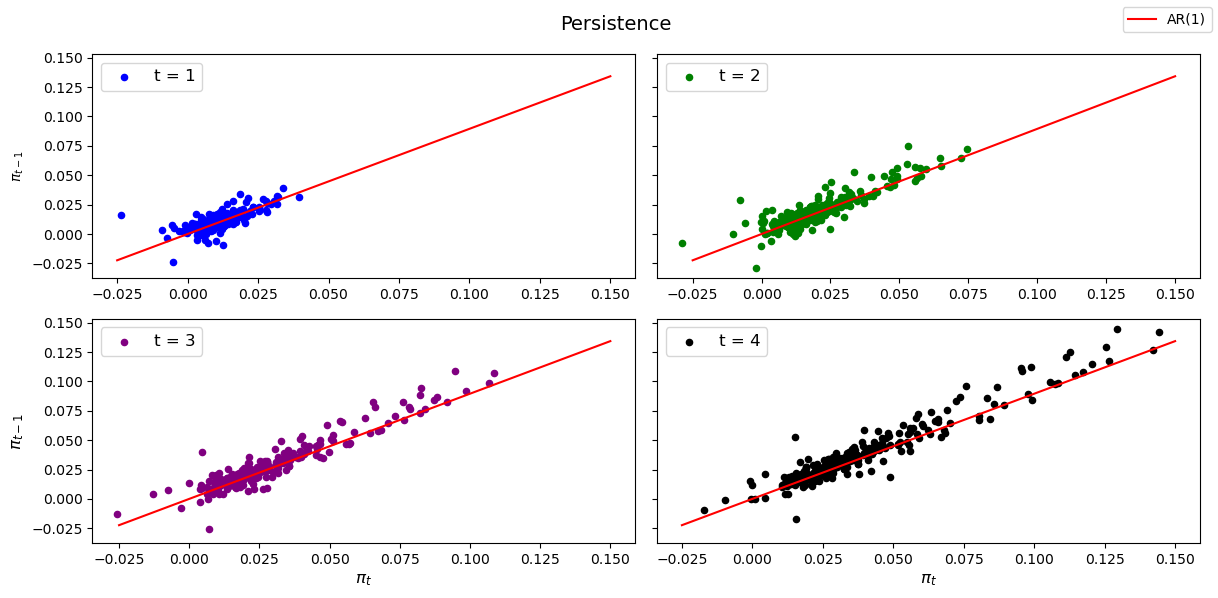

In [3]:
vintage_trim = vintage_trim.loc[(vintage_trim['DATE'] >= '1965-06-30') & (vintage_trim['DATE'] <= '2022-12-31')]
vintage_trim = vintage_trim[['t0', 't1', 't2', 't3', 't4', 'rec']]

model0 = ar_table.loc[0, 'coef'] * np.linspace(-0.025, 0.150)

fig, ((ax0, ax1), (ax2, ax3)) = plt.subplots(nrows=2, ncols=2, figsize=(12, 6), sharey=True,)
fig.suptitle('Persistence', fontsize=14)

ax0.scatter(vintage_trim['t0']['1965-09-30':], vintage_trim['t0'].shift(1)['1965-09-30':], c='blue', label=r't = 1', alpha=1, s=20)
ar_1 = ax0.plot(np.linspace(-0.025, 0.150), model0, color="red", lw=1.5, label='AR(1)')
ax0.set_ylabel(r'$\pi_{t-1}$', fontsize=10)
ax0.legend(['t = 1'], fontsize=12)

ax1.scatter(vintage_trim['t1']['1965-09-30':], vintage_trim['t1'].shift(1)['1965-09-30':], c='green', label='t = 2', alpha=1, s=20)
ax1.plot(np.linspace(-0.025, 0.150), model0, color="red", lw=1.5)
ax1.legend(['t = 2'], fontsize=12)

ax2.scatter(vintage_trim['t2']['1965-09-30':], vintage_trim['t2'].shift(1)['1965-09-30':], c='purple', label='t = 3', alpha=1, s=20)
ax2.plot(np.linspace(-0.025, 0.150), model0, color="red", lw=1.5)
ax2.set_ylabel(r'$\pi_{t-1}$', fontsize=12)
ax2.set_xlabel(r'$\pi_t$', fontsize=12)
ax2.legend(['t = 3'], fontsize=12)

ax3.scatter(vintage_trim['t3']['1965-09-30':], vintage_trim['t3'].shift(1)['1965-09-30':], c='black', label='t = 4', alpha=1, s=20)
ax3.plot(np.linspace(-0.025, 0.150), model0, color="red", lw=1.5)
ax3.set_xlabel(r'$\pi_t$', fontsize=12)
ax3.legend(['t = 4'], fontsize=12)

fig.legend(handles=ar_1)
plt.tight_layout()
plt.show()
fig.savefig('output/figures/ar_scat.svg', dpi=200)

# __II. Line Plots__

## A. Actuals v Forecasts

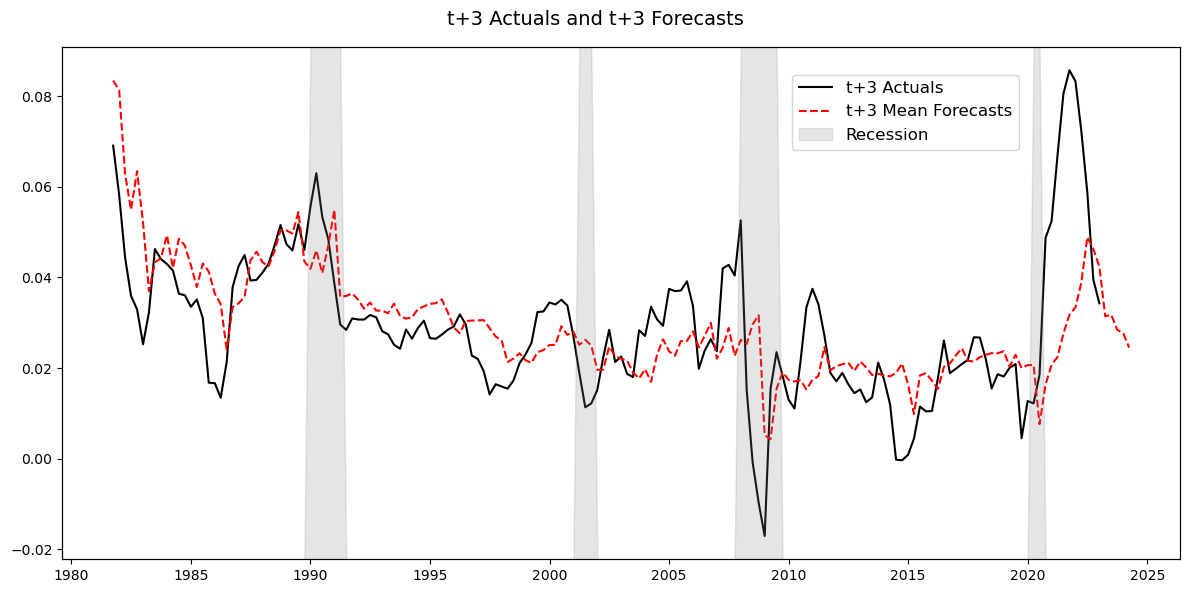

In [4]:
fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('t+3 Actuals and t+3 Forecasts', fontsize=14)

ax.plot(vintage_trim['1981-09-30':].index, vintage_trim['1981-09-30':]['t3'], color="k", lw=1.5, label='t+3 Actuals')
ax.plot(mean_spf_trim.index, mean_spf_trim['f_t3'], color='red', linestyle='dashed', lw=1.5, label='t+3 Mean Forecasts')

ax1 = ax.twinx()
ax1.fill_between(vintage_trim['1981-09-30':].index, 0, vintage_trim['1981-09-30':]['rec'], color='grey', alpha=0.2, label='Recession')
ax1.set_ylim(0, 1)
ax1.get_yaxis().set_visible(False)

fig.legend(loc='right', fontsize=12, bbox_to_anchor=(0.76, 0.75, 0.1, 0.12))
plt.tight_layout()
plt.show()
fig.savefig('output/figures/act_errors_line.svg', dpi=200)